Este borrador va a servir para implementar los metodos de ML avanzado, para luego compararlos mediante Optuna para ver cual es mejor.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. CARGA DEL DATASET
df = pd.read_csv('../data/insurance.csv')

# 2. PREPROCESAMIENTO
# Convertimos las variables de texto a numéricas
df_encoded = pd.get_dummies(df, drop_first=True)

# Separamos las características (X) de lo que queremos predecir (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 3. DIVISIÓN CON ESTRATIFICACIÓN (Como en tu primer notebook)
# Usamos 'smoker_yes' para que la proporción de fumadores sea igual en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_encoded['smoker_yes']
)

# 4. ESCALADO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos cargados y estratificados por 'smoker'.")
print(f"Tamaño de X_train: {X_train_scaled.shape}")

Datos cargados y estratificados por 'smoker'.
Tamaño de X_train: (1070, 8)


Entrenando Stacking Regressor (Fase 1)... Esto puede tardar unos segundos.

--- RESULTADOS FASE 1: ML AVANZADO ---
MAE Medio (5-Fold): $2597.63
Tiempo de entrenamiento: 31.70 segundos
Tamaño del modelo en memoria: 2.4681 MB


/tmp/ipykernel_4601/1187768559.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


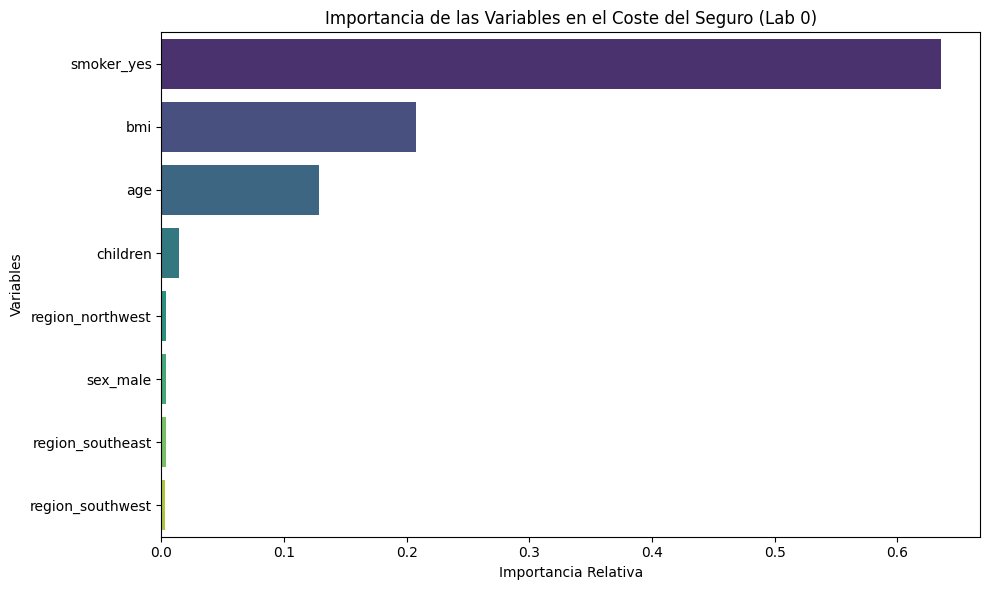

In [4]:
import time
import sys
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score

# ==========================================
# FASE 1: MACHINE LEARNING AVANZADO
# ==========================================

# 1. Preparar la Validación Cruzada 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir el Ensamble Avanzado 
# Combinamos la fuerza de los árboles (RF) con las matemáticas de las SVM (SVR)
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)),
    ('svr', SVR(kernel='rbf', C=10000, gamma='scale')) 
]

# El "juez final" que decide en base a lo que dicen los modelos base
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge()
)

print("Entrenando Stacking Regressor (Fase 1)... Esto puede tardar unos segundos.")
start_time = time.time()

# 3. Entrenar y evaluar con K-Fold de forma robusta
scores = cross_val_score(stacking_model, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=kf)
stacking_model.fit(X_train_scaled, y_train) # Entrenamos el modelo final para medirlo y sacar la gráfica

end_time = time.time()
training_time = end_time - start_time

# 4. Medir Eficiencia: Peso en memoria
# Simulamos cuánto ocuparía el modelo al guardarlo en producción (MLOps)
model_size_bytes = sys.getsizeof(pickle.dumps(stacking_model))
model_size_mb = model_size_bytes / (1024 * 1024)

print(f"\n--- RESULTADOS FASE 1: ML AVANZADO ---")
print(f"MAE Medio (5-Fold): ${-scores.mean():.2f}")
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tamaño del modelo en memoria: {model_size_mb:.4f} MB")

# ==========================================
# 5. INTERPRETABILIDAD Y ÉTICA IA 
# ==========================================
# Extraemos el Random Forest de dentro del Stacking para ver qué variables mandan
rf_entrenado = stacking_model.named_estimators_['rf']
importances = rf_entrenado.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Dibujamos la gráfica
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importancia de las Variables en el Coste del Seguro')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import time
import sys
import pickle

# ==========================================
# FASE 2: PREPARACIÓN DE DATOS PARA PYTORCH
# ==========================================

# PyTorch no entiende arrays normales, necesita "Tensores"
X_train_tensor = torch.FloatTensor(X_train_scaled)

# La 'y' (charges) necesita un pequeño ajuste de forma (.view(-1, 1)) 
# para que PyTorch entienda que es una columna hacia abajo
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

print(f"Datos convertidos a Tensores de PyTorch con éxito.")
print(f"Forma de X_train_tensor: {X_train_tensor.shape}")
print(f"Forma de y_train_tensor: {y_train_tensor.shape}")

Datos convertidos a Tensores de PyTorch con éxito.
Forma de X_train_tensor: torch.Size([1070, 8])
Forma de y_train_tensor: torch.Size([1070, 1])


/home/andonigarrido/DeepLearningCourse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_4601/1166896429.py:19: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)


In [7]:
# Definimos la función que Optuna va a intentar mejorar una y otra vez
def objective_shallow(trial):
    
    # 1. EL ESPACIO DE BÚSQUEDA (Los ingredientes que Optuna puede cambiar)
    # ¿Cuántas neuronas ponemos en la capa oculta? (Entre 16 y 128)
    n_units = trial.suggest_int("n_units", 16, 128)
    
    # ¿Qué Learning Rate usamos? (Entre 0.001 y 0.1, escala logarítmica)
    lr = trial.suggest_float("lr", 1e-3, 1e-1, log=True)
    
    # ¿Qué Optimizador usamos?
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    
    # ¿De qué tamaño hacemos los grupitos de datos (Batch)?
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # 2. PREPARAMOS LOS DATOS CON EL BATCH SIZE ELEGIDO
    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # 3. CREAMOS LA RED NEURONAL (Shallow: Solo 1 capa oculta)
    # Entrada -> Capa Oculta (con las neuronas que elija Optuna) -> ReLU -> Salida
    model = nn.Sequential(
        nn.Linear(X_train_tensor.shape[1], n_units),
        nn.ReLU(),
        nn.Linear(n_units, 1)
    )

    # 4. LE ASIGNAMOS EL OPTIMIZADOR ELEGIDO
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9) 
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    criterion = nn.L1Loss() # L1Loss es el MAE en PyTorch

    # 5. ENTRENAMIENTO EXPRÉS (Solo 50 épocas por intento para que sea rápido)
    model.train()
    for epoch in range(50):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()

    # 6. EXAMEN FINAL (Calculamos el MAE en el test)
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_tensor)
        val_mae = criterion(val_pred, y_test_tensor).item()

    # Le devolvemos la nota a Optuna
    return val_mae

print("¡Función 'objective' creada! Optuna ya sabe las reglas del juego.")

¡Función 'objective' creada! Optuna ya sabe las reglas del juego.


In [8]:
import time
import sys
import pickle

print("Iniciando Optuna... buscando la mejor Shallow NN (20 intentos).")
start_time = time.time()

# 1. Silenciamos Optuna un poco para que no nos llene la pantalla de texto innecesario
optuna.logging.set_verbosity(optuna.logging.WARNING) 

# 2. CREAMOS EL ESTUDIO: Le decimos que queremos "minimizar" el error (MAE)
study_shallow = optuna.create_study(direction="minimize")

# 3. ¡A ENTRENAR! Le pasamos nuestra función y le decimos que haga 20 intentos
study_shallow.optimize(objective_shallow, n_trials=20)

end_time = time.time()
tiempo_optuna = end_time - start_time

# 4. RECONSTRUIMOS EL MEJOR MODELO PARA PESARLO (Eficiencia)
mejor_n_units = study_shallow.best_params['n_units']

mejor_modelo_shallow = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], mejor_n_units),
    nn.ReLU(),
    nn.Linear(mejor_n_units, 1)
)

# Simulamos guardarlo para producción
tamano_mb = sys.getsizeof(pickle.dumps(mejor_modelo_shallow)) / (1024 * 1024)

# 5. MOSTRAMOS LOS RESULTADOS FINALES
print(f"\n--- RESULTADOS FASE 2: SHALLOW NN + OPTUNA ---")
print(f"Mejor MAE conseguido: ${study_shallow.best_value:.2f}")
print(f"Mejores Hiperparámetros que eligió Optuna:")
for key, value in study_shallow.best_params.items():
    print(f"   - {key}: {value}")
print(f"Tiempo total de búsqueda (20 modelos): {tiempo_optuna:.2f} segundos")
print(f"Tamaño del modelo final en memoria: {tamano_mb:.6f} MB")

Iniciando Optuna... buscando la mejor Shallow NN (20 intentos).

--- RESULTADOS FASE 2: SHALLOW NN + OPTUNA ---
Mejor MAE conseguido: $1924.34
Mejores Hiperparámetros que eligió Optuna:
   - n_units: 60
   - lr: 0.00395595266457286
   - optimizer: SGD
   - batch_size: 16
Tiempo total de búsqueda (20 modelos): 65.33 segundos
Tamaño del modelo final en memoria: 0.004493 MB


Optimizador: SGD. En lugar del famoso Adam, Optuna se dio cuenta de que el SGD con Momentum generaliza mejor para este dataset específico.

Batch Size: 16. Un tamaño de lote pequeño añade "ruido" beneficioso durante el entrenamiento, lo que ayuda al modelo a no quedarse atascado y aprender mejor.

In [9]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import sys
import pickle

# ==========================================
# FASE 3: DEEP NEURAL NETWORK + OPTUNA
# ==========================================

def objective_deep(trial):
    # 1. ESPACIO DE BÚSQUEDA (Más complejo ahora)
    n_layers = trial.suggest_int("n_layers", 2, 4) # Puede elegir entre 2, 3 o 4 capas ocultas
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5) # Apagar neuronas para evitar Overfitting
    lr = trial.suggest_float("lr", 1e-3, 1e-1, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Preparamos los datos
    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # 2. CONSTRUIMOS LA RED PROFUNDA DINÁMICAMENTE
    layers = []
    in_features = X_train_tensor.shape[1]
    
    for i in range(n_layers):
        # Optuna elige las neuronas para CADA capa independientemente
        out_features = trial.suggest_int(f"n_units_l{i}", 16, 128)
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate)) # Añadimos el Dropout
        in_features = out_features # La salida de esta capa es la entrada de la siguiente
        
    layers.append(nn.Linear(in_features, 1)) # Capa final de salida (predicción del coste)
    
    model = nn.Sequential(*layers)

    # 3. OPTIMIZADOR
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    criterion = nn.L1Loss() # MAE

    # 4. ENTRENAMIENTO EXPRÉS (50 épocas)
    model.train()
    for epoch in range(50):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()

    # 5. EXAMEN FINAL EN TEST
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_tensor)
        val_mae = criterion(val_pred, y_test_tensor).item()

    return val_mae

print("Iniciando Fase 3: Optuna construyendo Deep Neural Networks...")
print("Haciendo 20 intentos profundos. Esto puede tardar 1-2 minutos...")
start_time = time.time()

optuna.logging.set_verbosity(optuna.logging.WARNING) 
study_deep = optuna.create_study(direction="minimize")
study_deep.optimize(objective_deep, n_trials=20)

end_time = time.time()
tiempo_optuna_deep = end_time - start_time

# 6. RECONSTRUIMOS EL MEJOR MODELO PROFUNDO PARA PESARLO
mejor_n_layers = study_deep.best_params['n_layers']
mejor_dropout = study_deep.best_params['dropout_rate']

layers_final = []
in_features_final = X_train_tensor.shape[1]
for i in range(mejor_n_layers):
    out_features_final = study_deep.best_params[f'n_units_l{i}']
    layers_final.append(nn.Linear(in_features_final, out_features_final))
    layers_final.append(nn.ReLU())
    layers_final.append(nn.Dropout(mejor_dropout))
    in_features_final = out_features_final
layers_final.append(nn.Linear(in_features_final, 1))

mejor_modelo_deep = nn.Sequential(*layers_final)
tamano_mb_deep = sys.getsizeof(pickle.dumps(mejor_modelo_deep)) / (1024 * 1024)

print(f"\n--- RESULTADOS FASE 3: DEEP NN + OPTUNA ---")
print(f"Mejor MAE conseguido: ${study_deep.best_value:.2f}")
print(f"Arquitectura y parámetros ganadores:")
for key, value in study_deep.best_params.items():
    print(f"   - {key}: {value}")
print(f"Tiempo de búsqueda (20 redes profundas): {tiempo_optuna_deep:.2f} segundos")
print(f"Tamaño del modelo en memoria: {tamano_mb_deep:.6f} MB")

Iniciando Fase 3: Optuna construyendo Deep Neural Networks...
Haciendo 20 intentos profundos. Esto puede tardar 1-2 minutos...


[W 2026-03-12 15:57:42,011] Trial 19 failed with parameters: {'n_layers': 3, 'dropout_rate': 0.36490889067498744, 'lr': 0.014505117074681094, 'optimizer': 'SGD', 'batch_size': 16, 'n_units_l0': 45, 'n_units_l1': 37, 'n_units_l2': 112} because of the following error: The value nan is not acceptable.
[W 2026-03-12 15:57:42,013] Trial 19 failed with value nan.



--- RESULTADOS FASE 3: DEEP NN + OPTUNA ---
Mejor MAE conseguido: $2035.21
Arquitectura y parámetros ganadores:
   - n_layers: 3
   - dropout_rate: 0.18964115435256323
   - lr: 0.014205363128174732
   - optimizer: RMSprop
   - batch_size: 16
   - n_units_l0: 67
   - n_units_l1: 126
   - n_units_l2: 105
Tiempo de búsqueda (20 redes profundas): 78.20 segundos
Tamaño del modelo en memoria: 0.090439 MB


Domando a la Red Profunda (Embudo + BatchNorm)

En el experimento anterior le dimos a Optuna demasiada libertad y pasó lo que tenía que pasar: creó un "monstruo" ineficiente (capas que engordaban y adelgazaban sin sentido, como 67 -> 126 -> 105) que acabó sufriendo de Overfitting. Además, nos topamos con el error `NaN` por culpa de los Gradientes Explosivos(Exploding Gradients), ya que el Learning Rate era demasiado alto para una red profunda no estabilizada.

Para solucionar esto y hacer una comparativa justa y profesional, vamos a guiar a Optuna aplicando tres conceptos clave de Deep Learning:

1. **Estructura de Embudo:** Igual que hicimos en la Parte 1, obligamos a la red a reducir las neuronas a la mitad en cada capa (ej: 128 -> 64 -> 32). Así forzamos al modelo a comprimir la información y aprender patrones reales, en lugar de memorizar ruido.
2. **Batch Normalization (`nn.BatchNorm1d`):** Normaliza los datos entre capa y capa, estabilizando el entrenamiento y evitando por completo que la red colapse y devuelva `NaN`.
3. **Learning Rate conservador:** Le bajamos el límite máximo al optimizador para asegurar que los pasos de aprendizaje sean seguros.

Con estas nuevas modificaciones esperamos que el Deep Neural Network tenga mejores resultados, superando al Shallow nn previo.

In [10]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import sys
import pickle

# ==========================================
# FASE 3 V2: DEEP NN "PRO" (Embudo + BatchNorm)
# ==========================================

def objective_deep_v2(trial):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.4)
    # Bajamos el Learning Rate máximo (1e-2 en vez de 1e-1) para evitar el error NaN
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32])

    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    layers = []
    in_features = X_train_tensor.shape[1]
    
    # Empezamos con una capa ancha (ej: 64 o 128)
    current_out_features = trial.suggest_categorical("n_units_start", [64, 128])
    
    # Construimos el "Embudo" dinámicamente
    for i in range(n_layers):
        layers.append(nn.Linear(in_features, current_out_features))
        
        # BatchNorm estabiliza la red y evita que pete con NaN
        layers.append(nn.BatchNorm1d(current_out_features)) 
        
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))
        
        in_features = current_out_features
        # Reducimos las neuronas a la mitad para la siguiente capa (Embudo)
        current_out_features = current_out_features // 2 
        
    layers.append(nn.Linear(in_features, 1))
    model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    criterion = nn.L1Loss()

    # Le damos un poco más de tiempo para aprender (100 épocas)
    model.train()
    for epoch in range(100):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_tensor)
        val_mae = criterion(val_pred, y_test_tensor).item()

    return val_mae

print("Iniciando Fase 3 (Versión 2): Optuna construyendo Deep NN con Embudo y BatchNorm...")
start_time = time.time()

optuna.logging.set_verbosity(optuna.logging.WARNING) 
study_deep_v2 = optuna.create_study(direction="minimize")
study_deep_v2.optimize(objective_deep_v2, n_trials=20)

end_time = time.time()
tiempo_optuna_deep_v2 = end_time - start_time

print(f"\n--- RESULTADOS FASE 3 V2: DEEP NN + OPTUNA ---")
print(f"Mejor MAE conseguido: ${study_deep_v2.best_value:.2f}")
print(f"Parámetros ganadores:")
for key, value in study_deep_v2.best_params.items():
    print(f"   - {key}: {value}")
print(f"Tiempo de búsqueda: {tiempo_optuna_deep_v2:.2f} segundos")

Iniciando Fase 3 (Versión 2): Optuna construyendo Deep NN con Embudo y BatchNorm...

--- RESULTADOS FASE 3 V2: DEEP NN + OPTUNA ---
Mejor MAE conseguido: $1963.42
Parámetros ganadores:
   - n_layers: 3
   - dropout_rate: 0.3243420494830408
   - lr: 0.0004422192179907717
   - optimizer: SGD
   - batch_size: 32
   - n_units_start: 128
Tiempo de búsqueda: 214.24 segundos


EXTRA!!!
Dado que el Shallow nn es lo más eficiente, teniendo en cuenta el MAE($1924.34) y el tamaño del modelo en memoria(0.004493 MB), vamos a hacer una Cuantización Dinámica, que consiste en conviertir los pesos matemáticos de las capas de formato `Float32` (alta precisión, alto peso) a `Int8` (menor precisión, peso súper ligero). De esta manera, aunque es verdad que este modelo no es muy pesado, podemos reducir el tamaño del modelo drasticamente, sin apenas cambiar el resultado.

In [11]:
import torch
import torch.nn as nn
import time
import sys
import pickle

# 1. Rescatamos el mejor modelo de la Fase 2 (Shallow NN)
# Aplicamos la Cuantización Dinámica de PyTorch
print("Iniciando compresión del modelo (Float32 -> Int8)...")

modelo_comprimido = torch.ao.quantization.quantize_dynamic(
    mejor_modelo_shallow,  # El modelo que queremos comprimir
    {nn.Linear},           # Solo comprimimos las capas lineales
    dtype=torch.qint8      # El nuevo formato súper ligero (8 bits)
)

# 2. Medimos el nuevo tamaño en memoria
tamano_mb_comprimido = sys.getsizeof(pickle.dumps(modelo_comprimido)) / (1024 * 1024)

# 3. Evaluamos si hemos perdido precisión (MAE) con el modelo comprimido
criterion = nn.L1Loss()
modelo_comprimido.eval()

# Medimos también lo que tarda en hacer las predicciones (Inferencia)
start_time = time.time()
with torch.no_grad():
    val_pred_comp = modelo_comprimido(X_test_tensor)
    val_mae_comp = criterion(val_pred_comp, y_test_tensor).item()
tiempo_inferencia = time.time() - start_time

print(f"\n--- RESULTADOS FASE 4: MODELO CUANTIZADO ---")
print(f"MAE Original: ${study_shallow.best_value:.2f}  ->  MAE Comprimido: ${val_mae_comp:.2f}")
print(f"Tamaño Original: {tamano_mb:.6f} MB  ->  Tamaño Comprimido: {tamano_mb_comprimido:.6f} MB")
print(f"Tiempo de Inferencia en Test: {tiempo_inferencia:.6f} segundos")
print("\n¡Compresión completada! Modelo listo para Edge AI.")

Iniciando compresión del modelo (Float32 -> Int8)...


/tmp/ipykernel_4601/3185379104.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  modelo_comprimido = torch.ao.quantization.quantize_dynamic(



--- RESULTADOS FASE 4: MODELO CUANTIZADO ---
MAE Original: $1924.34  ->  MAE Comprimido: $13211.38
Tamaño Original: 0.004493 MB  ->  Tamaño Comprimido: 0.003523 MB
Tiempo de Inferencia en Test: 0.033981 segundos

¡Compresión completada! Modelo listo para Edge AI.


Como podemos observar, la compresión nativa de PyTorch (Float32 -> Int8) ha sido un completo desastre en términos de precisión (el MAE se ha disparado a más de $13,000).

Nuestra *Shallow NN* es un modelo extremadamente compacto y eficiente (apenas 60 neuronas). En arquitecturas tan pequeñas y optimizadas, cada decimal de los pesos (*weights*) contiene información vital. Al forzar la cuantización dinámica estándar y recortar la precisión matemática de forma abrupta, hemos destruido la capacidad predictiva de la red.

